In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv(r'/Users/abhiramireddygali/Downloads/May(2025)/8th-LOGISTIC REGRESSION CODE/logit classification.csv')

X = dataset.iloc[:,[2,3]]
y = dataset.iloc[:,-1]


In [2]:
X.shape

(400, 2)

In [3]:
X.columns

Index(['Age', 'EstimatedSalary'], dtype='object')

In [68]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20,random_state =0)

In [69]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 2)
(80, 2)
(320,)
(80,)


In [70]:
X_train

,Age,EstimatedSalary
336,58,144000
64,59,83000
55,24,55000
106,26,35000
300,58,38000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [71]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [72]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
y_pred = classifier.predict(X_test)

In [74]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1])

In [75]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[52  6]
 [ 3 19]]


In [76]:
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test,y_pred)
print(ac)

0.8875


In [77]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.95      0.90      0.92        58
           1       0.76      0.86      0.81        22

    accuracy                           0.89        80
   macro avg       0.85      0.88      0.86        80
weighted avg       0.89      0.89      0.89        80



In [78]:
variance = classifier.score(X_test,y_test)
print(variance)
bias = classifier.score(X_train,y_train)
print(bias)

0.8875
0.821875


In [79]:
from sklearn.metrics import roc_curve,roc_auc_score
y_prob = classifier.predict_proba(X_test)[:,1]

In [80]:
y_prob

array([0.22110696, 0.2628616 , 0.32245722, 0.17824297, 0.17032213,
       0.01687528, 0.02940367, 0.85349654, 0.01618966, 0.596285  ,
       0.07328368, 0.06275896, 0.2597929 , 0.51525256, 0.04174554,
       0.52944521, 0.42382208, 0.03385522, 0.99174522, 0.07411782,
       0.15653389, 0.97783916, 0.39047493, 0.92239216, 0.01064376,
       0.98294733, 0.16419246, 0.15726379, 0.30754773, 0.28399532,
       0.05304117, 0.44032694, 0.9428077 , 0.24706773, 0.03425717,
       0.00951618, 0.05051941, 0.1189042 , 0.0542821 , 0.62778014,
       0.14457607, 0.39850874, 0.12871972, 0.06963184, 0.87809089,
       0.05804145, 0.4486315 , 0.947406  , 0.01959647, 0.90064329,
       0.99251793, 0.06860898, 0.20621232, 0.6031917 , 0.9838939 ,
       0.41384479, 0.17110329, 0.09700738, 0.56307107, 0.00815326,
       0.03872319, 0.93987005, 0.02523599, 0.56187465, 0.00479387,
       0.98414389, 0.09142524, 0.05804145, 0.31779638, 0.59334018,
       0.77343872, 0.33732569, 0.02822366, 0.33527304, 0.14878

In [81]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)

print(auc_score)

0.9710031347962382


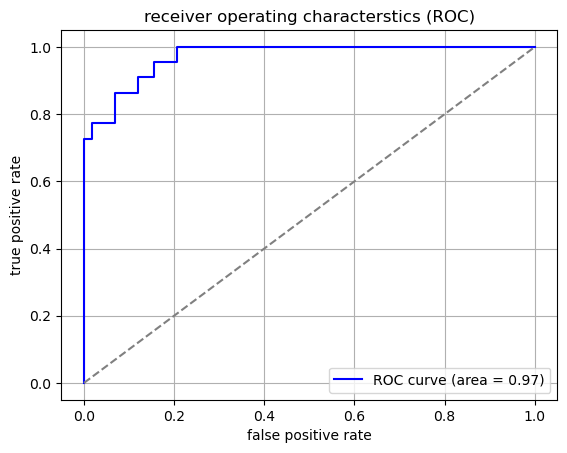

In [84]:
plt.figure()
plt.plot(fpr,tpr,color = 'blue',label ='ROC curve (area = %0.2f)'% auc_score)
plt.plot([0,1],[0,1],color = 'gray',linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('receiver operating characterstics (ROC)')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()
